# Ramsey RF far frequency scan

This notebook loads the CPU V3b scan over a wide RF-frequency range to
show the Ramsey fringe response away from resonance. The scan uses the
current production reduced-basis setting: `K=24`, `basis_dt=10 us`,
`dt_fine=0.05 us`, and no GPU methods.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Make the local benchmarks/ package importable from the notebook's CWD,
# whether it's opened from the repo root or from examples/ramsey_rf/.
_here = Path.cwd()
for _root in [_here, _here / "examples" / "ramsey_rf", _here.parent]:
    if (_root / "benchmarks" / "run_v3b_cpu_scans.py").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        _BENCH_ROOT = _root
        break
else:
    raise RuntimeError("Could not locate examples/ramsey_rf/benchmarks/")

from benchmarks.reference import F_RES  # noqa: E402
from benchmarks.run_v3b_cpu_scans import (  # noqa: E402
    BASIS_DT_US_DEFAULT,
    FRINGE_HZ,
    K_DEFAULT,
    run_frequency_scan,
)

plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 11,
    }
)


In [2]:
# Parameters — change here to alter what's computed.
# All numbers visible in the notebook; the heavy computation runs via
# `benchmarks.run_v3b_cpu_scans.run_frequency_scan`.

K = K_DEFAULT  # truncated subspace size (24)
BASIS_DT_US = BASIS_DT_US_DEFAULT  # adiabatic-tracking basis grid (10 us)
N_WORKERS = 8  # process-pool workers

MEAN_VELOCITY = 184.0  # m/s, monochromatic forward velocity
N_FREQ = 161  # frequency points across the scan window
FRINGES_WINDOW = 10.0  # +/- this many fringe spacings around F_RES

CACHE = _BENCH_ROOT / "benchmarks" / "_cache" / "v3b_far_frequency_scan_k24_basis10.npz"
print(f"F_RES        = {F_RES * 1e-3:.3f} kHz")
print(f"fringe spacing = {FRINGE_HZ:.3f} Hz")
print(
    f"window         = +/- {FRINGES_WINDOW * FRINGE_HZ:.1f} Hz "
    f"(+/- {FRINGES_WINDOW:.0f} fringe spacings)"
)
print(f"cache file     = {CACHE.name}")


F_RES        = 119.514 kHz
fringe spacing = 73.600 Hz
window         = +/- 736.0 Hz (+/- 10 fringe spacings)
cache file     = v3b_far_frequency_scan_k24_basis10.npz


In [3]:
# Load-or-compute. If the cached .npz is present, use it; otherwise run the
# scan now (~10 min on 8 cores) and save it in the same format the standalone
# script writes.
if CACHE.exists():
    print(f"Loading cached scan from {CACHE}")
    data = dict(np.load(CACHE))
else:
    print(
        f"Computing far-frequency scan ({N_FREQ} points, ~{N_FREQ * 7 / 60 / N_WORKERS:.1f} min "
        f"on {N_WORKERS} cores)..."
    )
    offsets = np.linspace(-FRINGES_WINDOW, FRINGES_WINDOW, N_FREQ)
    freqs = F_RES + offsets * FRINGE_HZ
    survival, elapsed_s, n_steps = run_frequency_scan(
        freqs,
        velocity=MEAN_VELOCITY,
        K=K,
        basis_dt_us=BASIS_DT_US,
        n_workers=N_WORKERS,
    )
    data = {
        "freqs": np.asarray(freqs),
        "offsets": np.asarray(offsets),
        "survival": np.asarray(survival),
        "mean_velocity": np.float64(MEAN_VELOCITY),
        "velocity": np.float64(MEAN_VELOCITY),
        "fringe_hz": np.float64(FRINGE_HZ),
        "K": np.int64(K),
        "basis_dt_us": np.float64(BASIS_DT_US),
        "n_workers": np.int64(N_WORKERS),
        "n_steps": np.int64(n_steps),
        "elapsed_s": np.float64(elapsed_s),
    }
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    np.savez(CACHE, **data)
    print(f"Done in {elapsed_s / 60:.2f} min, saved to {CACHE}")


Loading cached scan from C:\Users\Olivier\Documents\GitHub\CeNTREX-TlF\examples\ramsey_rf\benchmarks\_cache\v3b_far_frequency_scan_k24_basis10.npz


In [4]:
freqs = data["freqs"]
offsets = data["offsets"]
survival = data["survival"]
excitation = 1.0 - survival
fringe_hz = float(data["fringe_hz"])
detuning_hz = offsets * fringe_hz

summary = {
    "points": len(freqs),
    "range_fringes": (float(offsets.min()), float(offsets.max())),
    "range_hz": (float(detuning_hz.min()), float(detuning_hz.max())),
    "elapsed_min": float(data["elapsed_s"]) / 60.0,
    "K": int(data["K"]),
    "basis_dt_us": float(data["basis_dt_us"]),
    "survival_min": float(survival.min()),
    "survival_max": float(survival.max()),
    "excitation_max": float(excitation.max()),
}
summary


{'points': 161,
 'range_fringes': (-10.0, 10.0),
 'range_hz': (-736.0, 736.0),
 'elapsed_min': 280.3951769533334,
 'K': 24,
 'basis_dt_us': 10.0,
 'survival_min': 0.0014291539051186218,
 'survival_max': 0.9998740689057697,
 'excitation_max': 0.9985708460948813}

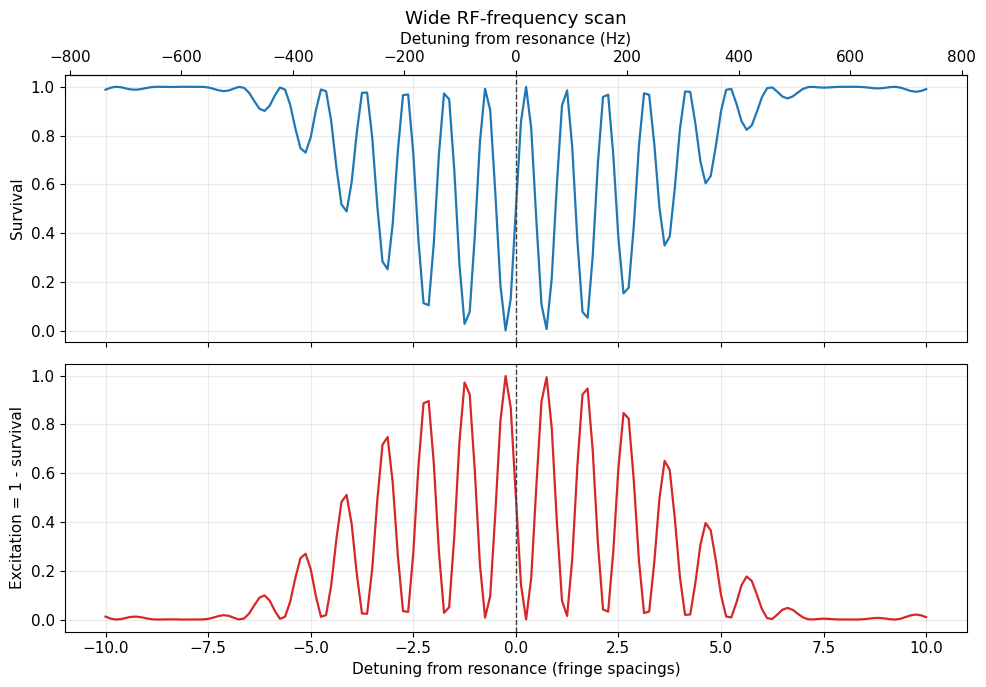

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axes[0].plot(offsets, survival, color="tab:blue", lw=1.6)
axes[0].axvline(0, color="0.25", lw=1, ls="--")
axes[0].set_ylabel("Survival")
axes[0].set_title("Wide RF-frequency scan")

axes[1].plot(offsets, excitation, color="tab:red", lw=1.6)
axes[1].axvline(0, color="0.25", lw=1, ls="--")
axes[1].set_xlabel("Detuning from resonance (fringe spacings)")
axes[1].set_ylabel("Excitation = 1 - survival")

top = axes[0].secondary_xaxis(
    "top",
    functions=(lambda x: x * fringe_hz, lambda x: x / fringe_hz),
)
top.set_xlabel("Detuning from resonance (Hz)")

fig.tight_layout()

In [6]:
central = np.abs(offsets) <= 2
outer = np.abs(offsets) >= 8
print(f"Central |offset| <= 2 fringes: excitation max = {excitation[central].max():.6f}")
print(f"Outer |offset| >= 8 fringes: excitation max = {excitation[outer].max():.6f}")
print(f"Outer |offset| >= 8 fringes: excitation min = {excitation[outer].min():.6f}")
print(f"Scan elapsed = {float(data['elapsed_s']) / 60:.2f} min")

Central |offset| <= 2 fringes: excitation max = 0.998571
Outer |offset| >= 8 fringes: excitation max = 0.020536
Outer |offset| >= 8 fringes: excitation min = 0.000148
Scan elapsed = 280.40 min


The lower panel is the useful view for the far-detuned behavior:
excitation is large near the Ramsey resonance structure and falls back
toward zero when the RF is far enough detuned that the pulses no longer
transfer much population.